# LoVoCCS 2D maps: Correlations between X-ray brightness and weak-lensing maps 

<span style="color:red">This section of the project investigates ...</span>

## Main takeaways 

In summary:

* We....

## Import Statements

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
from matplotlib import pyplot as plt
import os
from astropy.units import Quantity
from astropy.visualization import LinearStretch, ImageNormalize, LogStretch, MinMaxInterval
from astropy.wcs import WCS
from astropy.io import fits
from shutil import rmtree
from scipy.signal import correlate2d

# This adds the directory above to the path, allowing me to import the common functions that I've written in
#  common.py - this just saves me repeating boring code and makes sure its all consistent
import sys
sys.path.insert(0, '../')
from common import lovoccs_cosmo

import xga
# This just sets the number of cores this analysis is allowed to use
xga.NUM_CORES = 10
# This is a bodge that will only work because xga_output in notebooks has already been defined, XGA
#  will be made to handle this more gracefully at some point
temp_dir = xga.OUTPUT
actual_dir = temp_dir.split('notebooks/')[0]+'notebooks/xga_output/'
xga.OUTPUT = actual_dir
xga.utils.OUTPUT = actual_dir
# As currently XGA will setup an xga_output directory in our current directory, I remove it to keep it all clean
if os.path.exists('xga_output'):
    rmtree('xga_output')
from xga.samples import ClusterSample
from xga.products import Image, ExpMap, RateMap
from xga.imagetools.misc import pix_deg_scale

%matplotlib inline

## Useful values

Here we set up any values that are useful to several parts of the analysis in this notebook, and that we might wish to change in the future:

In [2]:
#

## Useful functions

Here we set up any functions used in this notebook:

In [3]:
def generate_wcs_matched_xmm_prod(src, lo_en, hi_en, wl_map):
    """
    This function replicates how XGA generates XMM images and exposure maps, and then how it combines them - this is 
    necessary because the stable version of XGA does not yet support generating images/exposure maps with custom binning.
    """

    wl_map_pix_deg_scale = wl_map.header['PC2_2']

    # Center to use for new images
    cent_coord = wl_map.coord_conv(Quantity([wl_map.shape[1]/2, wl_map.shape[0]/2], 'pix'), 'deg')
    
    # Need the CCF file for anything related to exposure maps, though not for images
    ccf_pth = "../xga_output/{oi}/ccf.cif"

    # In XMM detector coordinates, the lower and upper boundaries of the WL-WCS-matched images we're trying to make
    xmm_detcoord_bounds = [3649-263, 48885+263]

    add_expr = ""
    # The energy selection expression
    lo_chan = lo_en.to('eV').value.astype(int)
    hi_chan = hi_en.to('eV').value.astype(int)
        
    im_cmd = ("evselect table={e} imageset={i} xcolumn=X ycolumn=Y ximagebinsize={bs} "
              "yimagebinsize={bs} squarepixels=yes raimagecenter={ra_cen} decimagecenter={dec_cen} " 
              "ximagemin={l} ximagemax={u} withxranges=yes yimagemin={l} "
              "yimagemax={u} withyranges=yes {ex}")
    
    ex_cmd = ("export SAS_CCF={ccf}; eexpmap eventset={e} imageset={im} expimageset={eim} withdetcoords=no withvignetting=yes "
              "attitudeset={att} pimin={l} pimax={u}")
    mosaic_cmd = ("emosaic imagesets='{ims}' mosaicedset={mim}")
    
    for evt_list in src.get_products('events'):
        oi = evt_list.obs_id
        inst = evt_list.instrument
        
        with fits.open(evt_list.path) as fitso:
            xmm_det_deg_scale = fitso[0].header['REFYCDLT']
            
        xmm_binning = int(round(wl_map_pix_deg_scale / xmm_det_deg_scale, 0))

        if "pn" in inst:
            add_expr = "'#XMMEA_EP' && (PATTERN <= 4) && (FLAG .eq. 0)"
            
        else:
            add_expr = "'#XMMEA_EM' && (PATTERN <= 12) && (FLAG .eq. 0)"
            
        expr = " && ".join([e for e in ["expression='(PI in [{l}:{u}])".format(l=lo_chan, u=hi_chan), add_expr] if e != ""]) + "'"
        
        cur_im_cmd = im_cmd.format(e=evt_list.path, i='noupload_testo.fits', bs=xmm_binning, 
                                   ra_cen=round(cent_coord[0].value, 12), dec_cen=round(cent_coord[1].value, 12),
                                   l=xmm_detcoord_bounds[0], u=xmm_detcoord_bounds[1], ex=expr)

        cur_ex_cmd = ex_cmd.format(ccf=ccf_pth, e=evt_list.path, im='noupload_testo.fits', eim='noupload_testo_ex.fits')
        
        return cur_im_cmd


def im_corr(im_one, im_two):
    """
   
    """
    # Normalize each image by subtracting its mean and dividing by its standard deviation
    norm_im_one = (im_one - np.mean(im_one)) / np.std(im_one)
    norm_im_two = (im_two - np.mean(im_two)) / np.std(im_two)
    
    # Multiply the normalized arrays
    # This will be positive where both are high or both are low
    # and negative where they change in opposite directions
    im_corr = norm_im_one * norm_im_two
    
    return im_corr


## Output paths

Paths to save comparison figures and any output results files - defined here to avoid repetition and make the code easier to read: 

In [4]:
wlx_vis_path = "../../outputs/cluster_visualisations/xray_wlmass_maps/"
# os.makedirs(wlx_vis_path, exist_ok=True)

## Loading data files

Important considerations for this dataset:

* ...

### X-LoVoCCS-I base sample

In [5]:
xlovoccs_base = pd.read_csv("../../sample_files/X-LoVoCCSI.csv")
xlovoccs_base.insert(0, 'name', xlovoccs_base['LoVoCCSID'].apply(lambda x: "LoVoCCS-" + str(x)))
xlovoccs_base.head(6)

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4
0,LoVoCCS-1,1,1,A2029,227.734300,5.745471,0.0766,1.3344,227.73000,5.720000,227.734300,5.745471,8.726709e+44
1,LoVoCCS-2,2,2,A401,44.740000,13.580000,0.0739,1.2421,44.74000,13.580000,NaN,NaN,6.088643e+44
2,LoVoCCS-4A,4A,4,A85North,10.458750,-9.301944,0.0555,1.2103,10.45875,-9.301944,NaN,NaN,5.100085e+44
3,LoVoCCS-4B,4B,4,A85South,10.451487,-9.460007,0.0555,1.2103,10.45875,-9.301944,10.451487,-9.460007,5.100085e+44
4,LoVoCCS-5,5,5,A3667,303.157313,-56.845978,0.0556,1.1990,303.13000,-56.830000,303.157313,-56.845978,4.871933e+44
5,LoVoCCS-7,7,7,A3827,330.480000,-59.950000,0.0980,1.1367,330.48000,-59.950000,NaN,NaN,4.204419e+44


<span style="color:red">Maybe something more formal</span>

In [6]:
xlovoccs_samp = xlovoccs_base

## Loading LoVoCCS 2D weak-lensing SNR maps

In [7]:
wl_snr_map = Image("../../noupload_LoVoCCS-26_M_ap_SNR_b100_Rs13000.fits", '', '', '', '', '', Quantity(0.0, 'keV'), Quantity(0.0, 'keV'))
wl_snr_map_hdr = wl_snr_map.header

wl_snr_map_w = WCS(naxis=2)
key = ''

wl_snr_map_w.wcs.crpix = [wl_snr_map_hdr["CRPIX1{}".format(key)], wl_snr_map_hdr["CRPIX2{}".format(key)]]
wl_snr_map_w.wcs.cdelt = [wl_snr_map_hdr["PC1_1{}".format(key)], wl_snr_map_hdr["PC2_2{}".format(key)]]
wl_snr_map_w.wcs.crval = [wl_snr_map_hdr["CRVAL1{}".format(key)], wl_snr_map_hdr["CRVAL2{}".format(key)]]
wl_snr_map_w.wcs.ctype = [wl_snr_map_hdr["CTYPE1{}".format(key)], wl_snr_map_hdr["CTYPE2{}".format(key)]]

wl_snr_map._wcs_radec = wl_snr_map_w

/mnt/home/turne540/software/anaconda3/envs/xga_release/lib/python3.12/site-packages/xga/products/phot.py:182: UserWarning: You are loading an image with elements that are < 0, they will be set to 0.
  warnings.warn("You are loading an {} with elements that are < 0, "


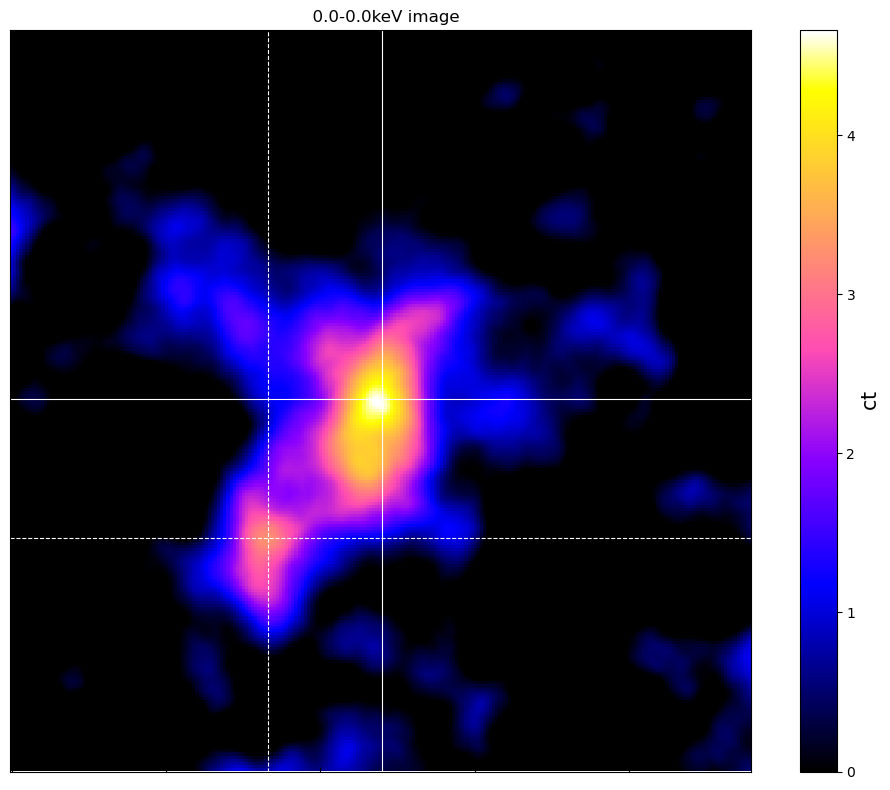

In [8]:
wl_snr_map.view(Quantity([[120, 120], [83, 75]], 'pix'), stretch=LinearStretch())

In [9]:
wl_snr_map.header


SIMPLE  =                    T / conforms to FITS standard
BITPIX  =                  -64 / array data type
NAXIS   =                    2 / number of array dimensions
NAXIS1  =                  240 / 
NAXIS2  =                  240 / 
WCSAXES =                    2 / Number of coordinate axes
CRPIX1  =      120.48993032876 / Pixel coordinate of reference point
CRPIX2  =       120.4850447804 / Pixel coordinate of reference point
PC1_1   =   -0.007305555555548 / Coordinate transformation matrix element
PC2_2   =   0.0073055555555479 / Coordinate transformation matrix element
CDELT1  =                  1.0 / [deg] Coordinate increment at reference point
CDELT2  =                  1.0 / [deg] Coordinate increment at reference point
CUNIT1  = 'deg'                / Units of coordinate increment and value
CUNIT2  = 'deg'                / Units of coordinate increment and value
CTYPE1  = 'RA---TAN'           / Right ascension, gnomonic projection
CTYPE2  = 'DEC--TAN'           / Declination

## Defining an XGA ClusterSample

In [10]:
xlovoccs_samp = xlovoccs_samp[~xlovoccs_samp['LoVoCCSID'].isin(['41C', '33'])]

**<span style="color:red">OBVIOUSLY REMOVE</span>**

In [11]:
xlovoccs_samp = xlovoccs_samp[xlovoccs_samp['name'].isin(['LoVoCCS-26', 'LoVoCCS-58'])]
xlovoccs_samp

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4
17,LoVoCCS-26,26,26,A2426,333.635833,-10.371667,0.0980,1.0442,333.635833,-10.371667,NaN,NaN,2.770068e+44
39,LoVoCCS-58,58,58,A2351,323.568242,-13.438889,0.0897,0.9604,323.570000,-13.480000,323.568242,-13.438889,1.793951e+44


In [12]:
srcs = ClusterSample(xlovoccs_samp['start_ra'].values, xlovoccs_samp['start_dec'].values, xlovoccs_samp['MCXC_Redshift'].values, 
                     xlovoccs_samp['name'].values, r500=Quantity(xlovoccs_samp['MCXC_R500'].values, 'Mpc'), use_peak=False, 
                     clean_obs=False, cosmology=lovoccs_cosmo)
srcs.info()

Setting up Galaxy Clusters: 100%|██████████| 2/2 [00:00<00:00,  2.13it/s]


-----------------------------------------------------
Number of Sources - 2
Redshift Information - True
Sources with ≥1 detection - 2 [100%]
-----------------------------------------------------



## Generating XMM count-rate maps matching WL map WCS

In [13]:
generate_wcs_matched_xmm_prod(srcs[0], Quantity(0.5, 'keV'), Quantity(2.0, 'keV'), wl_snr_map)

"evselect table=/mnt/ufs18/rs-033/mc2/LoVoCCS/X-LoVoCCS-Data/data/archives/LoVoCCS/processed_data/xmm_pointed/0675470601/events/obsid0675470601-instPN-subexpALL-en-finalevents.fits imageset=noupload_testo.fits xcolumn=X ycolumn=Y ximagebinsize=526 yimagebinsize=526 squarepixels=yes raimagecenter=333.610344416052 decimagecenter=-10.361558805245 ximagemin=3386 ximagemax=49148 withxranges=yes yimagemin=3386 yimagemax=49148 withyranges=yes expression='(PI in [500:2000]) && '#XMMEA_EP' && (PATTERN <= 4) && (FLAG .eq. 0)'"

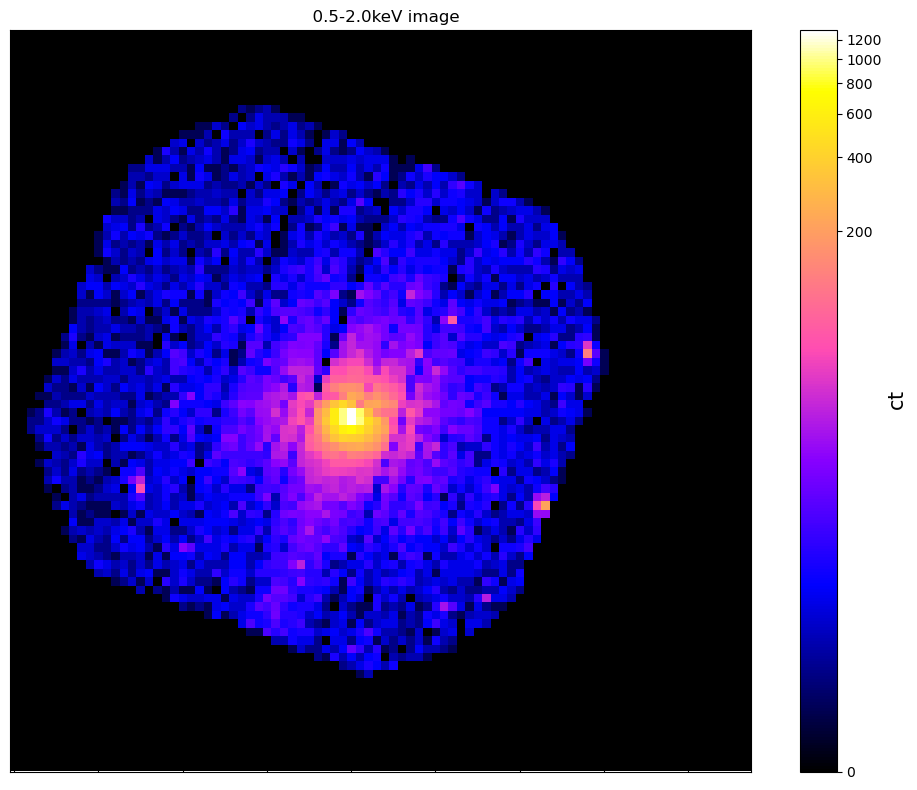

In [14]:
testo = Image('noupload_testo.fits', '', '', '', '', '', Quantity(0.5, 'keV'), Quantity(2.0, 'keV'))
testo.view()

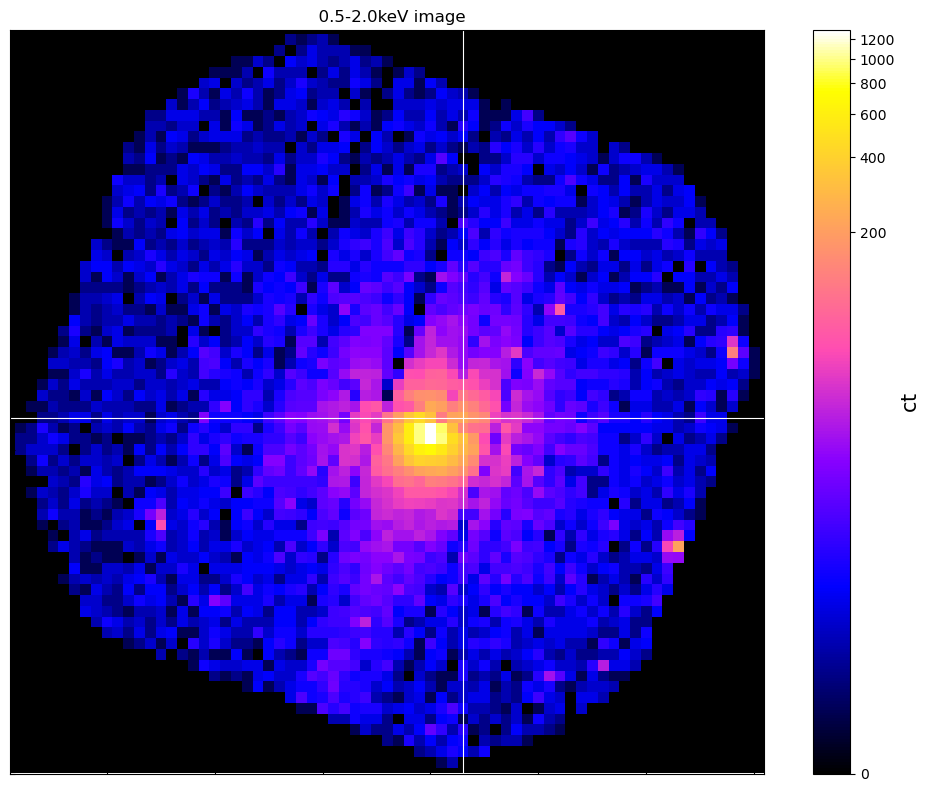

In [15]:
testo.view(Quantity([333.610344416052, -10.361558805245], 'deg'), zoom_in=True)

In [16]:
testo.coord_conv(Quantity([333.610344416052, -10.361558805245], 'deg'), 'pix')

<Quantity [43, 43] pix>

In [17]:
pad_testo = np.zeros(wl_snr_map.shape)
pad_testo

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [18]:
wl_snr_map.data[120, 120]

4.5822244009003725

In [19]:
testo.data[44, 44]

135.0

In [20]:
xray_sy_ind = int(testo.shape[0]/2)
xray_sx_ind = int(testo.shape[1]/2)

wl_sy_ind = int(wl_snr_map.shape[0]/2)
wl_sx_ind = int(wl_snr_map.shape[1]/2)

sel_dist = 43

rel_testo = testo.data[xray_sy_ind-sel_dist:xray_sy_ind+sel_dist+1, xray_sx_ind-sel_dist:xray_sx_ind+sel_dist+1]
pad_testo[wl_sy_ind-sel_dist:wl_sy_ind+sel_dist+1, wl_sx_ind-sel_dist:wl_sx_ind+sel_dist+1] = rel_testo

In [21]:
pad_testo.shape

(240, 240)

In [22]:
wl_snr_map.data[120, 120]

4.5822244009003725

In [23]:
pad_testo[120, 120]

135.0

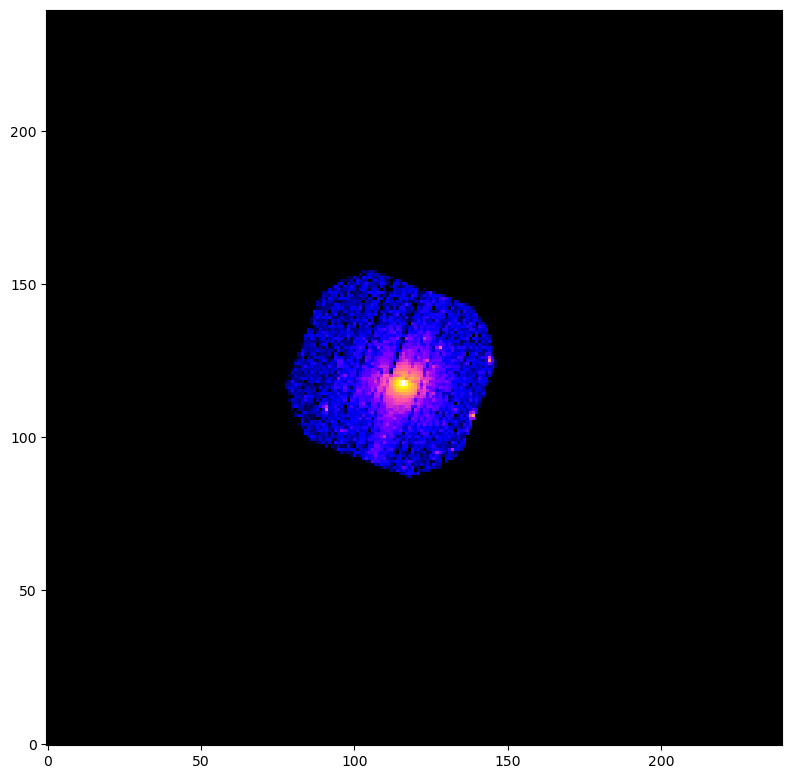

In [24]:
plt.figure(figsize=(8, 8))

norm = ImageNormalize(pad_testo, MinMaxInterval(), stretch=LogStretch())
plt.imshow(pad_testo, origin='lower', norm=norm, cmap='gnuplot2')

plt.tight_layout()
plt.show()

In [25]:
cur_corr = im_corr(wl_snr_map.data, pad_testo)

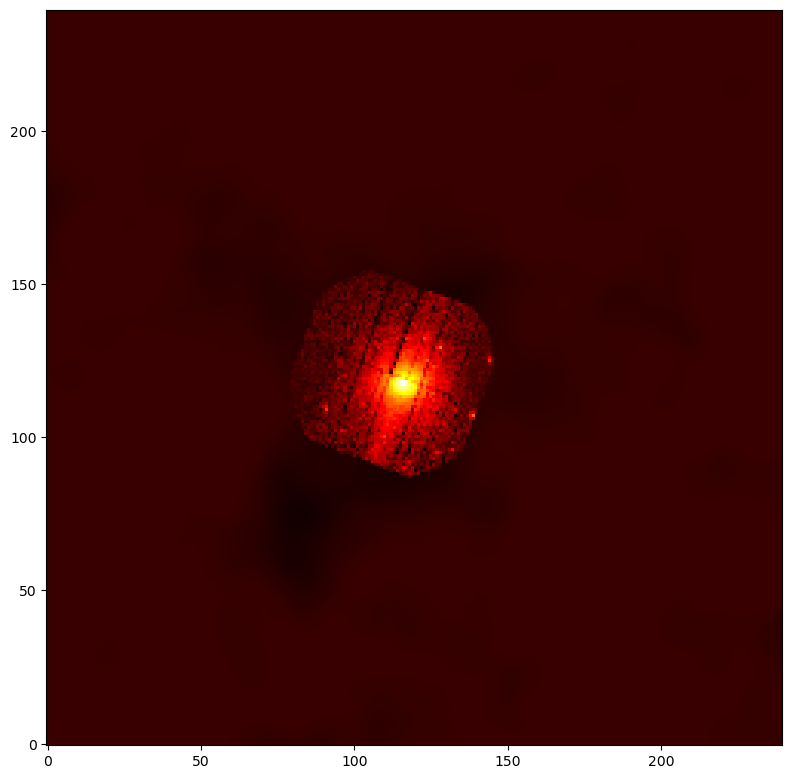

In [28]:
plt.figure(figsize=(8, 8))

norm = ImageNormalize(cur_corr, MinMaxInterval(), stretch=LogStretch())
plt.imshow(cur_corr, origin='lower', cmap='hot', norm=norm, interpolation='none')

plt.tight_layout()
plt.show()

1. "Image Matching by Normalized Cross-Correlation" (Zhao et al.)
2. Phase correlation (https://sthoduka.github.io/imreg_fmt/docs/phase-correlation/; DON'T KNOW THIS IS WHAT I WANT)
3. Mutual information metrics (https://matthew-brett.github.io/teaching/mutual_information.html; ALSO DON'T THINK THIS IS WHAT I WANT)
4. Structure Similarity Index (https://arxiv.org/abs/2101.06354)